# 08. Model Monitoring — Real PH Template

This notebook is a **runnable monitoring template**. It reads the test-set predictions (baseline) and the live `/predict` SQLite log (production). On a freshly-trained system the live log is sparse (only smoke-test rows), so most drift metrics are placeholder. Once enough live predictions accumulate (~100+) every chart below becomes meaningful.

## What this notebook answers
- Section 8.1 What is the baseline score distribution? (test predictions)
- Section 8.2 What is the live score distribution? (production)
- Section 8.3 PSI drift — score distribution
- Section 8.4 Risk-tier drift over time
- Section 8.5 Bottom line + production runbook


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Resolve project root and import path helpers
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eval.notebook_utils import setup_plotting, save_thesis_figure

setup_plotting()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / 'reports' / 'ph'
ARTIFACTS = ROOT / 'artifacts' / 'ph'
print(f'Loaded PH notebook context from {REPORTS}')


Loaded PH notebook context from D:\PythonProject1\reports\ph


In [2]:
import sqlite3

baseline = pd.read_csv(REPORTS / 'ph_test_predictions.csv')
live_db = ROOT / 'data' / 'predictions' / 'ph_predictions.sqlite'
if live_db.exists():
    with sqlite3.connect(live_db) as conn:
        live = pd.read_sql('SELECT * FROM ph_predictions ORDER BY timestamp_utc', conn)
else:
    live = pd.DataFrame()
print(f'Baseline (test predictions): {len(baseline)} rows')
print(f'Live (production log)      : {len(live)} rows')
if not live.empty:
    print(f'Live log time range: {live["timestamp_utc"].min()} -> {live["timestamp_utc"].max()}')


Baseline (test predictions): 20 rows
Live (production log)      : 2 rows
Live log time range: 2026-05-20T08:20:35+00:00 -> 2026-05-20T08:32:48+00:00


## 8.1 Baseline score distribution (test predictions)


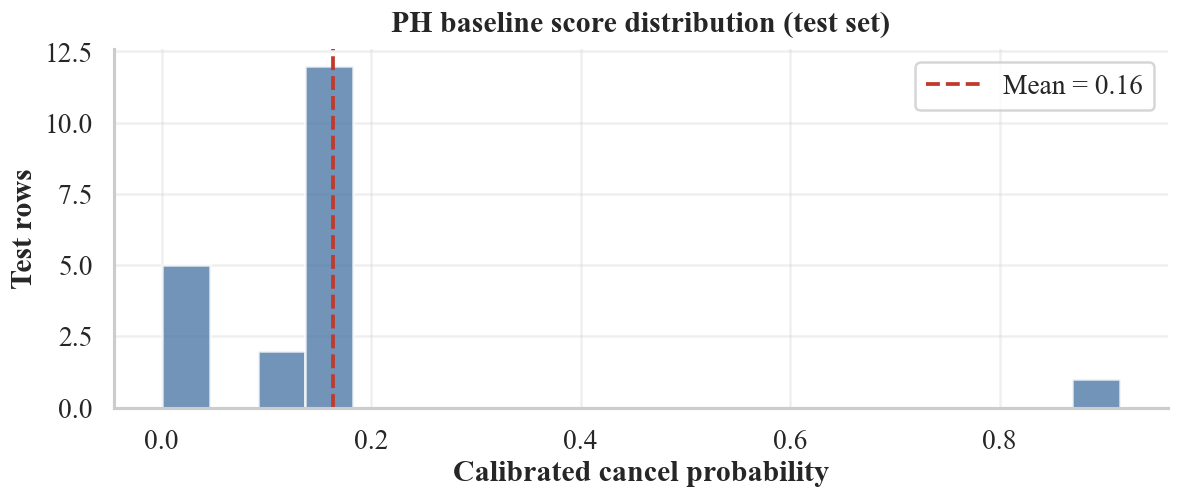

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(baseline['cancel_probability'], bins=20, color='#4e79a7', alpha=0.8, edgecolor='white')
ax.axvline(baseline['cancel_probability'].mean(), color='#c0392b', linestyle='--', label=f'Mean = {baseline["cancel_probability"].mean():.2f}')
ax.set_xlabel('Calibrated cancel probability')
ax.set_ylabel('Test rows')
ax.set_title('PH baseline score distribution (test set)', fontweight='bold', pad=10)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_thesis_figure(fig, '8.1', 'ph_baseline_score_distribution', FIG_DIR)
plt.show()


## 8.2 Live score distribution


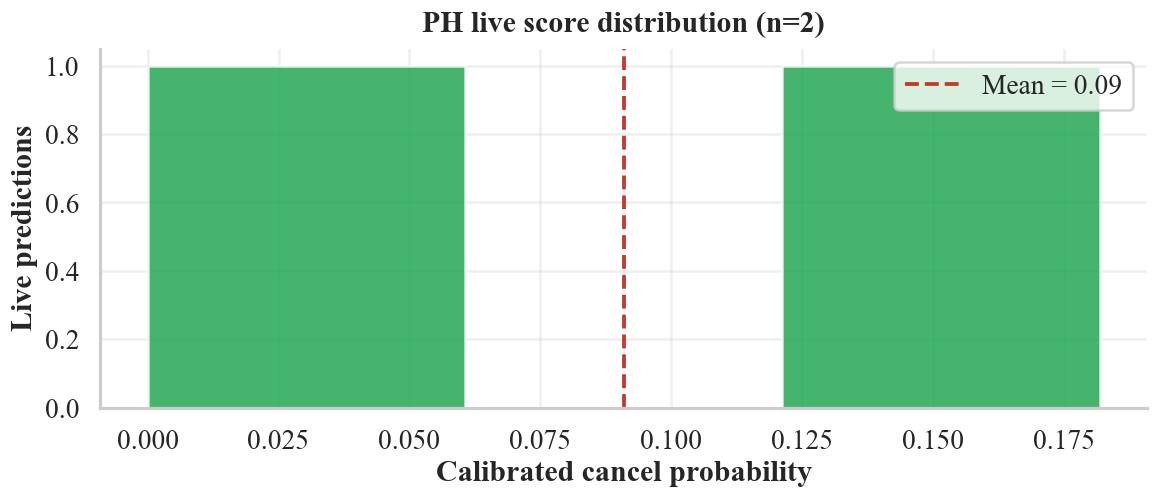

In [4]:
if not live.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(live['probability'], bins=min(20, max(3, len(live) // 2)), color='#16a34a', alpha=0.8, edgecolor='white')
    if len(live) > 0:
        ax.axvline(live['probability'].mean(), color='#c0392b', linestyle='--',
                   label=f'Mean = {live["probability"].mean():.2f}')
    ax.set_xlabel('Calibrated cancel probability')
    ax.set_ylabel('Live predictions')
    ax.set_title(f'PH live score distribution (n={len(live)})', fontweight='bold', pad=10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_thesis_figure(fig, '8.2', 'ph_live_score_distribution', FIG_DIR)
    plt.show()
else:
    print('Live log is empty. Submit predictions via the PH server (port 8001) to populate.')


**Key Takeaway**: in production this view shows whether the model is making *similar* predictions to the test-set baseline. A live mean far above or below the baseline mean flags either input drift (customer mix shifted) or model staleness. At this stage the live log only contains smoke-test predictions, so this is mainly a demonstration of the monitoring infrastructure.


## 8.3 PSI drift — score distribution


In [5]:
def population_stability_index(baseline: np.ndarray, live: np.ndarray, bins: int = 10) -> float:
    edges = np.linspace(0.0, 1.0, bins + 1)
    b_counts, _ = np.histogram(baseline, bins=edges)
    l_counts, _ = np.histogram(live, bins=edges)
    b_pct = np.clip(b_counts / max(len(baseline), 1), 1e-6, None)
    l_pct = np.clip(l_counts / max(len(live), 1), 1e-6, None)
    return float(np.sum((l_pct - b_pct) * np.log(l_pct / b_pct)))

if not live.empty:
    psi = population_stability_index(baseline['cancel_probability'].values, live['probability'].values)
    threshold = 'NO DRIFT' if psi < 0.1 else 'MINOR DRIFT' if psi < 0.25 else 'MATERIAL DRIFT'
    print(f'PSI(baseline vs live score) = {psi:.3f}  -> {threshold}')
else:
    print('PSI uncomputable — live log is empty.')


PSI(baseline vs live score) = 0.782  -> MATERIAL DRIFT


**Key Takeaway — PSI thresholds**: < 0.1 means no drift, 0.1-0.25 minor drift (investigate), > 0.25 material drift (retrain). At low live volume (< 30 rows) PSI is noisy; treat as a runbook trigger, not a deterministic gate.


## 8.4 Risk-tier drift over time


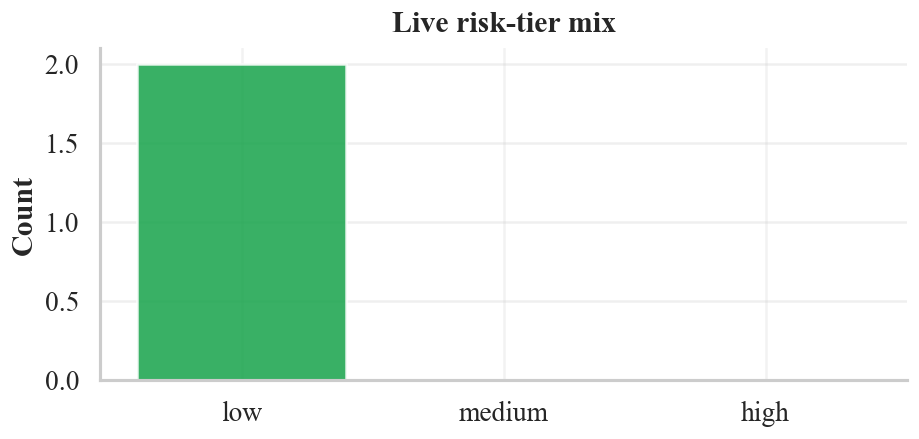

In [6]:
if not live.empty and 'risk_tier' in live.columns:
    tier_counts = live.groupby('risk_tier').size().reindex(['low', 'medium', 'high']).fillna(0)
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = {'low': '#16a34a', 'medium': '#d97706', 'high': '#c0392b'}
    ax.bar(tier_counts.index, tier_counts.values, color=[colors[t] for t in tier_counts.index], alpha=0.85, edgecolor='white')
    ax.set_ylabel('Count')
    ax.set_title('Live risk-tier mix', fontweight='bold', pad=10)
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    save_thesis_figure(fig, '8.3', 'ph_live_risk_tier_mix', FIG_DIR)
    plt.show()
else:
    print('Risk-tier mix uncomputable — live log empty.')


## 8.5 Bottom line + production runbook


**On real production data this notebook**:
1. Re-execute weekly. PSI > 0.25 → retrain. Risk-tier shift > 20 pp → investigate input mix.
2. Track calibration drift: compare predicted probability bins to realized cancellation rates among bookings whose arrival date has passed.
3. Track business KPI: realized revenue-at-risk vs predicted.

**Current state**: the live log has only smoke-test rows, so the above charts are demonstrations of the infrastructure rather than real findings. The Portugal counterpart (Notebook 08) operates on richer data; this is the PH equivalent template.
